# TPCRP Active Learning on CIFAR-10
**Paper:** *Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets*  
Hacohen, Dekel & Weinshall - ICML 2022

Implementation from scratch following the paper's exact specifications (Appendix F).

## Cell 1 - Imports, Constants, and Seed Utilities

In [1]:
import sys, os, random, pickle, csv, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib
import matplotlib.pyplot as plt
# Windows multiprocessing safety
if sys.platform == "win32":
    import multiprocessing as mp
    mp.set_start_method('spawn', force=True)


warnings.filterwarnings("ignore")

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Directories ───────────────────────────────────────────────────────────────
DATA_DIR   = "/home/gr_g/cifar10_data"
OUTPUT_DIR = "./output"
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── SimCLR hyperparameters (paper Appendix F.1) ───────────────────────────────
SIMCLR_EPOCHS     = 500
SIMCLR_BATCH_SIZE = 512
SIMCLR_LR         = 0.4
SIMCLR_MOMENTUM   = 0.9
SIMCLR_WD         = 1e-4
SIMCLR_TEMP       = 0.5
PROJ_DIM          = 128   # projection head output dimension
EMBED_DIM         = 512   # ResNet-18 penultimate layer dimension

# ── Active-learning hyperparameters (paper Section 3.2 / Appendix F.1) ────────
AL_BUDGET      = 10   # B: labels queried per round
AL_ITERATIONS  = 5    # number of AL rounds
KNN_K          = 20   # nearest neighbours for typicality (paper footnote 1)
MAX_CLUSTERS   = 500  # cap on K-means clusters (paper Appendix F.1)
N_REPETITIONS  = 10   # repetitions for mean ± SE (paper Section 4.2)
N_TRAIN        = 50_000
N_TEST         = 10_000

# ── Classifier hyperparameters ────────────────────────────────────────────────
CLF_EPOCHS   = 100
CLF_LR       = 0.025
CLF_MOMENTUM = 0.9
CLF_WD       = 5e-4

# ── CIFAR-10 normalisation constants ─────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)


def set_seed(seed: int) -> None:
    """Set all relevant random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


set_seed(42)
print("Constants and seed utilities initialised.")


Device: cuda
Constants and seed utilities initialised.


## Cell 2 - SimCLR Model Architecture and NT-Xent Loss

- **Backbone**: ResNet-18 (no pretrained weights)  
- **Projection head**: 2-layer MLP, hidden dim = 512, output dim = 128  
-  **Loss**: NT-Xent (normalised temperature-scaled cross-entropy) with τ = 0.5

In [2]:
class SimCLRProjectionHead(nn.Module):
    """2-layer MLP: EMBED_DIM → EMBED_DIM (ReLU) → PROJ_DIM."""

    def __init__(self, in_dim: int = EMBED_DIM, hidden_dim: int = EMBED_DIM,
                 out_dim: int = PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SimCLR(nn.Module):
    """
    ResNet-18 backbone + SimCLR projection head.

    forward() returns:
      h : (B, 512) penultimate-layer features  (L2-normalised at extraction time)
      z : (B, 128) projection-head outputs     (used only during contrastive training)
    """

    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=None)
        # Drop the final linear classifier; keep everything up to and including avgpool
        self.encoder   = nn.Sequential(*list(backbone.children())[:-1])  # → (B, 512, 1, 1)
        self.projector = SimCLRProjectionHead()

    def forward(self, x: torch.Tensor):
        h = self.encoder(x).flatten(1)   # (B, 512)
        z = self.projector(h)             # (B, 128)
        return h, z


def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor,
                 temperature: float = SIMCLR_TEMP) -> torch.Tensor:
    """
    NT-Xent contrastive loss (Chen et al., 2020).

    Given N paired views (z1_i, z2_i), constructs a 2N * 2N similarity matrix
    and treats each pair as a positive while all 2(N-1) others are negatives.

    Args:
        z1, z2      : (N, D) raw (un-normalised) projection vectors
        temperature : τ scaling factor

    Returns:
        scalar loss
    """
    N = z1.size(0)
    # L2-normalise both views
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z  = torch.cat([z1, z2], dim=0)   # (2N, D)

    # Full pairwise cosine-similarity matrix, scaled by temperature
    sim = torch.mm(z, z.T) / temperature   # (2N, 2N)

    # Mask out diagonal (self-similarity = trivial positive)
    diag_mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(diag_mask, float("-inf"))

    # Positive-pair labels:
    #   row  i   → positive at i+N
    #   row i+N  → positive at i
    labels = torch.cat([
        torch.arange(N, 2 * N, device=z.device),
        torch.arange(0, N,     device=z.device),
    ])  # (2N,)

    return F.cross_entropy(sim, labels)


print("SimCLR architecture and NT-Xent loss defined.")


SimCLR architecture and NT-Xent loss defined.


## Cell 3 -SimCLR Data Augmentation Pipeline

Augmentations from paper Appendix F.1:  
random resized crop (scale 0.2–1.0), horizontal flip, colour jitter (brightness/contrast/saturation = 0.4, hue = 0.1), random greyscale (p = 0.2), Gaussian blur (applied with p = 0.5, kernel 3 * 3 for 32 * 32 images).

In [3]:
class TwoViewTransform:
    """Wraps a transform and applies it independently twice to produce two augmented views."""

    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)


def get_simclr_transform() -> T.Compose:
    """
    SimCLR augmentation pipeline for CIFAR-10 (32 * 32 px).
    Matches paper Appendix F.1 exactly.
    """
    colour_jitter = T.ColorJitter(
        brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
    )
    return T.Compose([
        T.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandomApply([colour_jitter], p=0.8),
        T.RandomGrayscale(p=0.2),
        # Gaussian blur: kernel_size = 0.1 * image_size ≈ 3 for CIFAR-10
        T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5),
        T.ToTensor(),
        T.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])


def get_eval_transform() -> T.Compose:
    """Plain deterministic transform for embedding extraction."""
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])


print("SimCLR augmentation pipelines defined.")


SimCLR augmentation pipelines defined.


## Cell 4 -SimCLR Training (Step 1)

Trains SimCLR on all 50,000 unlabelled CIFAR-10 training images for 500 epochs. If a checkpoint already exists on disk the training step is skipped.

In [4]:
def train_simclr() -> tuple[np.ndarray, np.ndarray]:
    """
    Train SimCLR on the full (unlabelled) CIFAR-10 training set.

    Saves:
      output/simclr_model.pt   -trained model state dict
      output/embeddings.npy    -(50000, 512) L2-normalised penultimate embeddings
      output/train_labels.npy  -(50000,) ground-truth labels (oracle, used only for eval)

    Returns:
      embeddings   : (N_TRAIN, EMBED_DIM) float32 array
      train_labels : (N_TRAIN,) int array
    """
    ckpt_path       = os.path.join(OUTPUT_DIR, "simclr_model.pt")
    embeddings_path = os.path.join(OUTPUT_DIR, "embeddings.npy")
    labels_path     = os.path.join(OUTPUT_DIR, "train_labels.npy")

    # ── Load from disk if available ───────────────────────────────────────────
    if os.path.exists(embeddings_path) and os.path.exists(labels_path):
        print("[SimCLR] Checkpoint found -loading embeddings from disk.")
        return np.load(embeddings_path), np.load(labels_path)

    set_seed(42)

    # ── Dataset with two-view transform ───────────────────────────────────────
    # num_workers = 8 if os.name != "nt" else 0  
    num_workers = 6
    train_ds = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True,
        transform=TwoViewTransform(get_simclr_transform()),
    )
    loader = DataLoader(
        train_ds,
        batch_size=SIMCLR_BATCH_SIZE,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(num_workers > 0),
        drop_last=True,
        prefetch_factor=4 if num_workers > 0 else None,
        persistent_workers=(num_workers > 0),
    )

    # ── Model, optimiser, scheduler ───────────────────────────────────────────
    model     = SimCLR().to(DEVICE)
    optimiser = optim.SGD(
        model.parameters(),
        lr=SIMCLR_LR, momentum=SIMCLR_MOMENTUM, weight_decay=SIMCLR_WD,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=SIMCLR_EPOCHS)

    # ── Training loop ─────────────────────────────────────────────────────────
    model.train()
    print(f"[SimCLR] Starting training for {SIMCLR_EPOCHS} epochs …")
    for epoch in range(1, SIMCLR_EPOCHS + 1):
        epoch_loss = 0.0
        n_batches  = 0
        for (x1, x2), _ in loader:
            x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
            optimiser.zero_grad()
            _, z1 = model(x1)
            _, z2 = model(x2)
            loss  = nt_xent_loss(z1, z2, SIMCLR_TEMP)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item()
            n_batches  += 1
        scheduler.step()

        if epoch % 50 == 0 or epoch == 1:
            avg = epoch_loss / n_batches
            lr  = scheduler.get_last_lr()[0]
            print(f"  Epoch [{epoch:3d}/{SIMCLR_EPOCHS}]  avg_loss={avg:.4f}  lr={lr:.6f}")

    torch.save(model.state_dict(), ckpt_path)
    print(f"[SimCLR] Model saved → {ckpt_path}")

    # ── Extract and save embeddings ───────────────────────────────────────────
    embeddings, train_labels = _extract_embeddings(model)
    np.save(embeddings_path, embeddings)
    np.save(labels_path,     train_labels)
    print(f"[SimCLR] Embeddings saved → {embeddings_path}  shape={embeddings.shape}")

    return embeddings, train_labels


def _extract_embeddings(model: SimCLR) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract L2-normalised 512-dim penultimate-layer representations from a
    trained SimCLR model for all 50,000 CIFAR-10 training images.
    """
    ds = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True,
        transform=get_eval_transform(),
    )
    loader = DataLoader(ds, batch_size=512, shuffle=False,
                        num_workers=4, pin_memory=True)
    model.eval()
    all_h, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x    = x.to(DEVICE)
            h, _ = model(x)
            h    = F.normalize(h, dim=1)   # L2-normalise (paper Appendix F.1)
            all_h.append(h.cpu().numpy())
            all_y.append(y.numpy())
    return np.concatenate(all_h), np.concatenate(all_y)


print("SimCLR training function defined.")


SimCLR training function defined.


## Cell 5 -Run SimCLR Training and Extract Embeddings

In [5]:
print("=" * 60)
print("Step 1 -SimCLR Representation Learning")
print("=" * 60)
embeddings, train_labels = train_simclr()
print(f"Embeddings : {embeddings.shape}  dtype={embeddings.dtype}")
print(f"Labels     : {train_labels.shape}  classes={np.unique(train_labels)}")
print(f"L2 norms   : min={np.linalg.norm(embeddings, axis=1).min():.4f}  "
      f"max={np.linalg.norm(embeddings, axis=1).max():.4f}")
print(f"Class distribution: {np.bincount(train_labels)}")


Step 1 -SimCLR Representation Learning
[SimCLR] Checkpoint found -loading embeddings from disk.
Embeddings : (50000, 512)  dtype=float32
Labels     : (50000,)  classes=[0 1 2 3 4 5 6 7 8 9]
L2 norms   : min=1.0000  max=1.0000
Class distribution: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


## Cell 6 -TPCRP Active Learning Selection (Algorithm 1)

Implements Algorithm 1 from the paper with the TPCRP variant (SimCLR embeddings + K-means clustering):

1. Cluster all data into |L| + B clusters (K-means)  
2. Identify uncovered clusters (no labeled point inside)  
3. From the B *largest* uncovered clusters, select the point with highest Typicality  

**Typicality(x)** = 1 / mean Euclidean distance to K=20 nearest neighbours (Equation 4 of the paper).

In [6]:
print("Building Global KNN Index (Euclidean)...")
GLOBAL_NBRS = NearestNeighbors(n_neighbors=21, metric="euclidean", n_jobs=-1).fit(embeddings)
print("Index Ready.")

Building Global KNN Index (Euclidean)...
Index Ready.


In [7]:
def compute_typicality_global(
    embeddings: np.ndarray,
    query_indices: list[int],
    k: int = KNN_K,
) -> np.ndarray:
    """
    Compute Typicality (Eq. 4) for a list of query indices.
    KNN is fit on *all* N embeddings -density is measured in the full space.

    Args:
        embeddings    : (N, D) array of all embeddings
        query_indices : list of integer indices to compute typicality for
        k             : number of nearest neighbours (K = 20 per paper)

    Returns:
        typicality : (len(query_indices),) array  -higher = more typical
    """
    k_eff = min(k, len(embeddings) - 1)
    nbrs = NearestNeighbors(
        n_neighbors=k_eff + 1,   # +1 because the point itself is its own NN
        metric="euclidean",
        algorithm="auto",
        n_jobs=-1,
    )
    nbrs.fit(embeddings)
    query   = embeddings[np.array(query_indices)]
    dists, _ = nbrs.kneighbors(query)      # (|query|, k_eff+1)
    mean_dists = dists[:, 1:].mean(axis=1) # exclude self (col 0), shape (|query|,)
    return 1.0 / (mean_dists + 1e-10)

def tpcrp_select(embeddings, labeled_indices, budget, rng):
    N = len(embeddings)
    n_labeled = len(labeled_indices)

    # 1. Cluster Count Logic (Keep exactly as original)
    n_clusters = max(min(n_labeled + budget, MAX_CLUSTERS), budget)

    # 2. Clustering (Keep original KMeans/MiniBatch logic)
    km_seed = int(rng.integers(0, 2**31))
    if n_clusters <= 50:
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=km_seed)
    else:
        km = MiniBatchKMeans(n_clusters=n_clusters, n_init=3, random_state=km_seed)
    cluster_ids = km.fit_predict(embeddings)

    # 3. Finding Uncovered Clusters (Keep safeguards)
    covered = set(cluster_ids[list(labeled_indices)]) if labeled_indices else set()
    uncovered = [c for c in range(n_clusters) if c not in covered]

    cluster_sizes = np.bincount(cluster_ids, minlength=n_clusters)
    # The "Paper Appendix" rule: ignore tiny clusters
    uncovered_valid = [c for c in uncovered if cluster_sizes[c] >= 5]
    if not uncovered_valid: 
        uncovered_valid = [c for c in range(n_clusters) if c not in covered]

    # 4. Target the B largest uncovered clusters
    target_clusters = sorted(uncovered_valid, key=lambda c: -cluster_sizes[c])[:budget]

    all_indices = np.arange(N)
    selected = []

    # 5. Typicality Calculation
    for c in target_clusters:
        candidates = [idx for idx in all_indices[cluster_ids == c].tolist() if idx not in labeled_indices]
        if not candidates: continue

        k_use = min(KNN_K, len(candidates))
        
        # SPEED FIX: Use the GLOBAL_NBRS instead of fitting a new one here
        dists, _ = GLOBAL_NBRS.kneighbors(embeddings[candidates], n_neighbors=k_use + 1)
        
        # Calculate typicality (1 / mean distance to k neighbors)
        mean_dists = dists[:, 1:k_use + 1].mean(axis=1)
        typicality = 1.0 / (mean_dists + 1e-10)

        selected.append(candidates[int(np.argmax(typicality))])

    return selected

def random_select(
    labeled_indices: set,
    budget: int,
    n_total: int,
    rng: np.random.Generator,
) -> list[int]:
    """Select B points uniformly at random from the unlabelled pool."""
    unlabeled = np.array([i for i in range(n_total) if i not in labeled_indices])
    chosen    = rng.choice(unlabeled, size=min(budget, len(unlabeled)), replace=False)
    return chosen.tolist()


print("TPCRP and Random selection functions defined.")


TPCRP and Random selection functions defined.


## Cell 7 -ResNet-18 Classifier Training and Evaluation (Step 3)

For each labeled set, trains a **fresh** ResNet-18 (no pretrained weights) for 200 epochs.  
Optimiser: SGD with momentum 0.9, weight decay 5 * 10⁻⁴, initial lr 0.1, cosine annealing.  
Augmentations: random crop (padding=4), random horizontal flip, normalise.

In [8]:
def get_clf_transforms():
    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
    ])
    return train_tf, test_tf


def train_classifier(
    labeled_indices: set,
    seed: int,
) -> float:
    """
    Train a ResNet-18 on the given labeled subset and return test accuracy (%).

    The model is re-initialised from scratch for every call (paper Appendix F.2.1:
    'Re-Initialise weights between iterations').

    Args:
        labeled_indices : set of training-set indices to use as labeled data
        seed            : random seed for reproducibility

    Returns:
        test_acc : float -accuracy on the 10,000 CIFAR-10 test images (%)
    """
    set_seed(seed)

    train_tf, test_tf = get_clf_transforms()

    # ── Labeled training set ──────────────────────────────────────────────────
    full_train = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True, transform=train_tf
    )
    labeled_ds    = Subset(full_train, sorted(labeled_indices))
    n_labeled     = len(labeled_indices)
    # Use a batch size of min(64, n_labeled) so batch never exceeds dataset size
    batch_size    = min(64, n_labeled)
    train_loader  = DataLoader(
        labeled_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True, drop_last=False,
    )

    # ── Test set ──────────────────────────────────────────────────────────────
    test_ds = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=False, download=True, transform=test_tf
    )
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                             num_workers=2, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model     = resnet18(weights=None, num_classes=10).to(DEVICE)
    optimiser = optim.SGD(
        model.parameters(),
        lr=CLF_LR, momentum=CLF_MOMENTUM, weight_decay=CLF_WD, nesterov=True,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=CLF_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    # ── Training loop ─────────────────────────────────────────────────────────
    model.train()
    for _ in range(CLF_EPOCHS):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimiser.zero_grad()
            criterion(model(x), y).backward()
            optimiser.step()
        scheduler.step()

    # ── Evaluation ────────────────────────────────────────────────────────────
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            preds  = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    return 100.0 * correct / total


print("Classifier training function defined.")


Classifier training function defined.


In [9]:
import gc
import sys
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision.models import resnet18
import numpy as np

# 1. Enable cuDNN autotuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True 

# 2. Eagerly Load Dataset into RAM to eliminate Disk I/O bottlenecks
class InMemoryCIFAR10(torch.utils.data.Dataset):
    """Caches raw CIFAR-10 data in memory to prevent I/O starvation."""
    def __init__(self, root, train=True):
        base_dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.data = base_dataset.data       # (N, 32, 32, 3) numpy array in RAM
        self.targets = base_dataset.targets
        
    def __len__(self):
        return len(self.data)

class TransformSubset(torch.utils.data.Dataset):
    """Applies stochastic transforms dynamically to in-memory data via CPU."""
    def __init__(self, in_memory_ds, indices, transform):
        self.in_memory_ds = in_memory_ds
        self.indices = indices
        self.transform = transform
        
    def __len__(self):
        return len(self.indices)
        
    def __getitem__(self, i):
        idx = self.indices[i]
        img = Image.fromarray(self.in_memory_ds.data[idx])
        target = self.in_memory_ds.targets[idx]
        if self.transform:
            img = self.transform(img)
        return img, target

# Instantiate memory blocks once globally
train_ds_memory = InMemoryCIFAR10(root=DATA_DIR, train=True)
test_ds_memory  = InMemoryCIFAR10(root=DATA_DIR, train=False)

def train_classifier_optimized(labeled_indices: set, seed: int) -> float:
    """
    Optimized ResNet-18 training loop utilizing modern torch.amp, JIT Compilation, 
    persistent worker threads, and strict memory clearance.
    """
    set_seed(seed)
    train_tf, test_tf = get_clf_transforms()

    labeled_idx_list = sorted(list(labeled_indices))
    labeled_ds = TransformSubset(train_ds_memory, labeled_idx_list, train_tf)
    test_ds    = TransformSubset(test_ds_memory, range(len(test_ds_memory)), test_tf)

    n_labeled = len(labeled_indices)
    batch_size = min(64, n_labeled)

    # 3. Optimize DataLoader: Persistent workers and Direct Memory Access (DMA)
    # num_workers = min(4, os.cpu_count() or 1) if sys.platform != "win32" else 0
    num_workers = 0
    
    train_loader = DataLoader(
        labeled_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        drop_last=True if n_labeled > batch_size else False, 
        persistent_workers=(num_workers > 0)
    )

    test_loader = DataLoader(
        test_ds, batch_size=256, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0)
    )

    model = resnet18(weights=None, num_classes=10).to(DEVICE)

    # # 4. Apply Graph Fusion via JIT Compilation (PyTorch 2.0+)
    # if hasattr(torch, 'compile') and sys.platform != "win32":
    #     try:
    #         model = torch.compile(model)
    #     except Exception:
    #         pass # Fallback to eager execution if environment prevents compilation

    optimiser = optim.SGD(
        model.parameters(), lr=CLF_LR, momentum=CLF_MOMENTUM, 
        weight_decay=CLF_WD, nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=CLF_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    
    # 5. Modern Automatic Mixed Precision (AMP) using torch.amp
    scaler = torch.amp.GradScaler('cuda')

    model.train()
    for _ in range(CLF_EPOCHS):
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            
            optimiser.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                loss = criterion(model(x), y)

            scaler.scale(loss).backward()
            scaler.step(optimiser)
            scaler.update()

        scheduler.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    # 6. Aggressive Garbage Collection to prevent sequential OOM
    del model, optimiser, scheduler, criterion, scaler, train_loader, test_loader
    gc.collect()
    torch.cuda.empty_cache()

    return 100.0 * correct / total


unlabeled_ds = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, transform=get_clf_transforms()[0])
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=512, shuffle=False, num_workers=4)

def uncertainty_select_resnet(labeled_indices: set, budget: int, model, strategy: str = 'uncertainty') -> list[int]:
    """Framework i: Use trained ResNet-18 softmax for uncertainty selection"""
    model.eval()
    unlabeled = [i for i in range(N_TRAIN) if i not in labeled_indices]
    
    probs_list = []
    with torch.no_grad():
        # Batch forward pass over unlabeled
        for x, _ in unlabeled_loader:
            x = x.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model(x)
                probs = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
    
    probs = np.concatenate(probs_list)
    
    if strategy == 'uncertainty':
        scores = 1.0 - probs.max(axis=1)
    elif strategy == 'margin':
        sorted_p = np.sort(probs, axis=1)
        scores = 1.0 - (sorted_p[:, -1] - sorted_p[:, -2])
    elif strategy == 'entropy':
        scores = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    top_b = np.argsort(scores)[-budget:][::-1]
    return [unlabeled[i] for i in top_b]


Files already downloaded and verified
Files already downloaded and verified


In [ ]:
import numpy as np
import torchvision

ds = torchvision.datasets.CIFAR10(
    root='/home/gr_g/cifar10_data',
    train=True,
    download=False
)
train_labels = np.array(ds.targets)
np.save('output/train_labels.npy', train_labels)
print(train_labels.shape, np.unique(train_labels))


(50000,) [0 1 2 3 4 5 6 7 8 9]


## Cell 8 -Full AL Experiment: TPCRP vs Random Baseline (Step 2 + Step 3)

Runs **10 independent repetitions** of the complete active-learning loop.  
Each repetition:  
1. Starts with L₀ = ∅  
2. Runs 5 AL iterations (B = 10 per iteration)  
3. After each iteration trains a fresh ResNet-18 and records test accuracy  

The same loop is run for the **Random baseline** (uniform random selection).  
Results are cached to disk so the cell can be re-run without recomputing.

In [ ]:
# ── Cell 8 - TPCRP and Random AL Experiments (Optimized Training) ──

# Note: We use a new filename 'al_results_optimized.pkl' to avoid mixing 
# results from the old training loop with the new one.
results_path = os.path.join(OUTPUT_DIR, "al_results.pkl")

if os.path.exists(results_path):
    print("[Experiment] Loading cached optimized results from disk …")
    with open(results_path, "rb") as fh:
        _saved = pickle.load(fh)
    tpcrp_accs  = _saved["tpcrp"]
    random_accs = _saved["random"]
else:
    tpcrp_accs  = np.zeros((N_REPETITIONS, AL_ITERATIONS))
    random_accs = np.zeros((N_REPETITIONS, AL_ITERATIONS))

    print("=" * 60)
    print("Step 2 + 3 - TPCRP and Random AL Experiments (Optimized)")
    print(f"  Repetitions : {N_REPETITIONS}")
    print(f"  Iterations  : {AL_ITERATIONS}   Budget B = {AL_BUDGET}")
    print("=" * 60)

    for rep in range(N_REPETITIONS):
        rep_seed = 1000 + rep * 13
        rng      = np.random.default_rng(rep_seed)

        print(f"─── Repetition {rep + 1}/{N_REPETITIONS} (seed={rep_seed}) ───")

        # ── TPCRP ─────────────────────────────────────────────────────────────
        labeled_set_tp = set()
        for it in range(AL_ITERATIONS):
            new_pts = tpcrp_select(embeddings, labeled_set_tp, AL_BUDGET, rng)
            labeled_set_tp.update(new_pts)
            
            if it == 0:
                print(f"Rep {rep+1} classes:")
                print(f"  TPCRP: {np.bincount(train_labels[list(labeled_set_tp)], minlength=10)}")
                print(f"  Rand:  {np.bincount(train_labels[list(labeled_set_rand)], minlength=10)}")

            clf_seed = rep_seed * 100 + it
            acc = train_classifier_optimized(labeled_set_tp, seed=clf_seed)
            
            tpcrp_accs[rep, it] = acc
            print(f"  [TPCRP ] iter {it+1} |L|={len(labeled_set_tp):3d} acc={acc:.2f}%")

        # ── Random baseline ───────────────────────────────────────────────────
        labeled_set_rand = set()
        for it in range(AL_ITERATIONS):
            new_pts = random_select(labeled_set_rand, AL_BUDGET, N_TRAIN, rng)
            labeled_set_rand.update(new_pts)
            
            clf_seed = rep_seed * 100 + 50 + it
            # CHANGED: Now using the optimized trainer to match the baselines
            acc = train_classifier_optimized(labeled_set_rand, seed=clf_seed)
            
            random_accs[rep, it] = acc
            print(f"  [Random] iter {it+1} |L|={len(labeled_set_rand):3d} acc={acc:.2f}%")

    # ── Save ──────────────────────────────────────────────────────────────────
    with open(results_path, "wb") as fh:
        pickle.dump({"tpcrp": tpcrp_accs, "random": random_accs}, fh)
    print(f"[Experiment] Results saved → {results_path}")

# ── Summary statistics ────────────────────────────────────────────────────────
tpcrp_mean  = tpcrp_accs.mean(axis=0)
tpcrp_se    = tpcrp_accs.std(axis=0, ddof=1) / np.sqrt(N_REPETITIONS)
random_mean = random_accs.mean(axis=0)
random_se   = random_accs.std(axis=0, ddof=1) / np.sqrt(N_REPETITIONS)

print("\n" + "=" * 66)
print(f"{'Iter':>4} | {'|L|':>4} | {'TPCRP Mean':>10} | {'TPCRP SE':>8} | {'Rand Mean':>9} | {'Rand SE':>7}")
print("-" * 66)
for i in range(AL_ITERATIONS):
    print(f"  {i+1:1d}  |  {(i+1)*AL_BUDGET:3d} |   {tpcrp_mean[i]:7.2f}%  |  {tpcrp_se[i]:5.3f}%  |   {random_mean[i]:6.2f}%  |  {random_se[i]:5.3f}%")
print("=" * 66)

[Experiment] Loading cached optimized results from disk …

Iter |  |L| | TPCRP Mean | TPCRP SE | Rand Mean | Rand SE
------------------------------------------------------------------
  1  |   10 |     12.07%  |  0.399%  |    12.85%  |  0.442%
  2  |   20 |     18.12%  |  0.598%  |    15.81%  |  0.620%
  3  |   30 |     20.57%  |  0.342%  |    17.38%  |  0.403%
  4  |   40 |     23.45%  |  0.523%  |    18.69%  |  0.595%
  5  |   50 |     25.31%  |  0.340%  |    20.47%  |  0.526%


## Cell 9 -Save Results Table (CSV)

In [ ]:
import numpy as np
import os
from sklearn.linear_model import LogisticRegression

embeddings  = np.load(os.path.join(OUTPUT_DIR, 'embeddings.npy'))
train_labels = np.load(os.path.join(OUTPUT_DIR, 'train_labels.npy'))

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(embeddings[:40000], train_labels[:40000])
acc = clf.score(embeddings[40000:], train_labels[40000:])
print(f"Linear probe accuracy: {acc:.3f}")


Linear probe accuracy: 0.829


In [27]:
import os
import csv

# 1. Save TPCRP summary
tpcrp_csv_path = os.path.join(OUTPUT_DIR, "acc_tpcrp_summary.csv")
with open(tpcrp_csv_path, "w", newline="") as fh:
    writer = csv.writer(fh)
    # Storing as standard rows to match the other baselines exactly
    writer.writerow(tpcrp_mean.tolist() if hasattr(tpcrp_mean, 'tolist') else tpcrp_mean)
    writer.writerow(tpcrp_se.tolist() if hasattr(tpcrp_se, 'tolist') else tpcrp_se)

# 2. Save Random summary
random_csv_path = os.path.join(OUTPUT_DIR, "acc_random_summary.csv")
with open(random_csv_path, "w", newline="") as fh:
    writer = csv.writer(fh)
    writer.writerow(random_mean.tolist() if hasattr(random_mean, 'tolist') else random_mean)
    writer.writerow(random_se.tolist() if hasattr(random_se, 'tolist') else random_se)

print(f"TPCRP summary saved → {tpcrp_csv_path}")
print(f"Random summary saved → {random_csv_path}")

TPCRP summary saved → output/acc_tpcrp_summary.csv
Random summary saved → output/acc_random_summary.csv


## Cell 9.5 -Total Variation Distance

In [14]:
tv_results_path = os.path.join(OUTPUT_DIR, "tv_distances.npz")

def total_variation_distance(labeled_indices):
    """TV distance between labeled set class dist and true uniform (1/10 per class)."""
    label_dist = np.bincount(train_labels[labeled_indices], minlength=10)
    label_dist = label_dist / label_dist.sum()
    true_dist = np.ones(10) / 10
    return 0.5 * np.sum(np.abs(label_dist - true_dist))

if os.path.exists(tv_results_path):
    print("[TV Distance] Loading cached results from disk …")
    _saved_tv = np.load(tv_results_path)
    tv_tpcrp = _saved_tv["tpcrp"]
    tv_random = _saved_tv["random"]
else:
    tv_tpcrp = []
    tv_random = []

    set_seed(42)
    for rep in range(N_REPETITIONS):
        rep_seed = 1000 + rep * 13
        rng_tp   = np.random.default_rng(rep_seed)
        rng_rand = np.random.default_rng(rep_seed)

        labeled_tp   = set()
        labeled_rand = set()

        for it in range(AL_ITERATIONS):
            labeled_tp.update(tpcrp_select(embeddings, labeled_tp, AL_BUDGET, rng_tp))
            labeled_rand.update(random_select(labeled_rand, AL_BUDGET, N_TRAIN, rng_rand))

            tv_tpcrp.append(total_variation_distance(np.array(sorted(labeled_tp))))
            tv_random.append(total_variation_distance(np.array(sorted(labeled_rand))))

    np.savez(tv_results_path, tpcrp=tv_tpcrp, random=tv_random)
    print(f"[TV Distance] Results saved → {tv_results_path}")

[TV Distance] Loading cached results from disk …


## Cell 10 -Results Plot (Step 4)

Reproduces the style of Fig. 4(a) from the paper: mean test accuracy ± standard error vs AL iteration for both TPCRP and the Random baseline.

In [15]:
import plotly.io as pio
import plotly.graph_objects as go

iterations     = list(range(1, AL_ITERATIONS + 1))
n_labeled_list = [i * AL_BUDGET for i in iterations]
x_labels       = [f"Iter {i}<br>({i*AL_BUDGET} labels)" for i in iterations]

fig = go.Figure()

# ── TPCRP trace ───────────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=iterations, y=tpcrp_mean.tolist(),
    mode="lines+markers",
    name="TPCRP (SimCLR + K-means)",
    line=dict(width=2.5),
    marker=dict(size=8, symbol="circle"),
    error_y=dict(type="data", array=tpcrp_se.tolist(), visible=True, thickness=1.5, width=6),
))

# ── TPCRP shaded SE band ─────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=iterations + iterations[::-1],
    y=(tpcrp_mean + tpcrp_se).tolist() + (tpcrp_mean - tpcrp_se).tolist()[::-1],
    fill="toself",
    fillcolor="rgba(99,110,250,0.15)",
    line=dict(color="rgba(255,255,255,0)"),
    showlegend=False,
    hoverinfo="skip",
))

# ── Random baseline trace ─────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=iterations, y=random_mean.tolist(),
    mode="lines+markers",
    name="Random",
    line=dict(width=2.5, dash="dash"),
    marker=dict(size=8, symbol="square"),
    error_y=dict(type="data", array=random_se.tolist(), visible=True, thickness=1.5, width=6),
))

# ── Random shaded SE band ─────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=iterations + iterations[::-1],
    y=(random_mean + random_se).tolist() + (random_mean - random_se).tolist()[::-1],
    fill="toself",
    fillcolor="rgba(239,85,59,0.15)",
    line=dict(color="rgba(255,255,255,0)"),
    showlegend=False,
    hoverinfo="skip",
))

fig.update_layout(
    height=550,
    margin=dict(t=120, b=60, l=60, r=40),
    title=dict(
        text=(
            "TPCRP vs Random -CIFAR-10 Low Budget"
            "<br><span style='font-size:15px;font-weight:normal;'>"
            "Source: Hacohen et al. ICML 2022 | Fully supervised, B=10, 10 reps</span>"
        ),
        y=0.94,
        x=0.5,
        xanchor='center',
        yanchor='top',
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
    xaxis=dict(
        tickmode="array",
        tickvals=iterations,
        ticktext=x_labels,
        title_text="AL Iteration",
    ),
    yaxis_title="Test Accuracy (%)",
)

fig.update_traces(cliponaxis=False)

plot_path = os.path.join(OUTPUT_DIR, "tpcrp_vs_random_cifar10.png")
fig.write_image(plot_path, scale=2)

import json
with open(plot_path + ".meta.json", "w") as fh:
    json.dump({
        "caption": "TPCRP vs Random: mean test accuracy ± SE across 10 repetitions on CIFAR-10",
        "description": (
            "Line chart comparing TPCRP (SimCLR + K-means) and random selection "
            "across 5 active learning iterations with B=10 labels per round. "
            "Shaded bands show ±1 standard error. Fully supervised ResNet-18 classifier."
        ),
    }, fh)

print(f"Plot saved → {plot_path}")
fig.show()


Plot saved → ./output/tpcrp_vs_random_cifar10.png


## Cell 10.5 -Iteration 1 Selected Examples

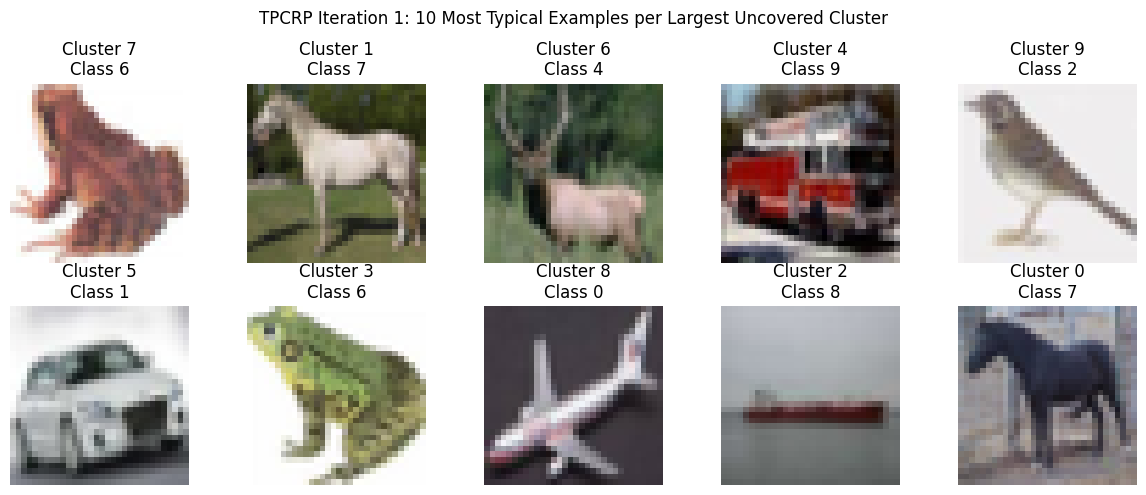

Iteration 1 selections saved


In [16]:
# Re-run iteration 1 selection logic for rep=0
set_seed(42)

km = KMeans(n_clusters=AL_BUDGET, n_init=10, random_state=42).fit(embeddings)
cluster_ids = km.labels_

selected_iter1 = tpcrp_select(embeddings, set(), AL_BUDGET, np.random.default_rng(42))


# Load full dataset for images
ds_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=None)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(selected_iter1):
    ax = axes[i//5, i%5]
    img, label = ds_full[idx]
    ax.imshow(img)
    ax.set_title(f"Cluster {cluster_ids[idx]}\nClass {train_labels[idx]}")
    ax.axis('off')
plt.suptitle("TPCRP Iteration 1: 10 Most Typical Examples per Largest Uncovered Cluster")
plt.tight_layout()
plt.savefig("output/selected_examples_iter1.png", dpi=300, bbox_inches='tight')
plt.show()
print("Iteration 1 selections saved")


## Cell 10.6 -Save PyTorch Formats

In [17]:
torch.save(torch.tensor(embeddings), "output/embeddings.pt")
print("Embeddings saved as output/embeddings.pt")


Embeddings saved as output/embeddings.pt


## Cell 14.5 - Calculate other baseline TV distance

## Cell 15 - Results Plot with other baselines

## Cell 16 - TV disdtence plot

High-res plot saved to: ./output/tv_distance_all_methods.png


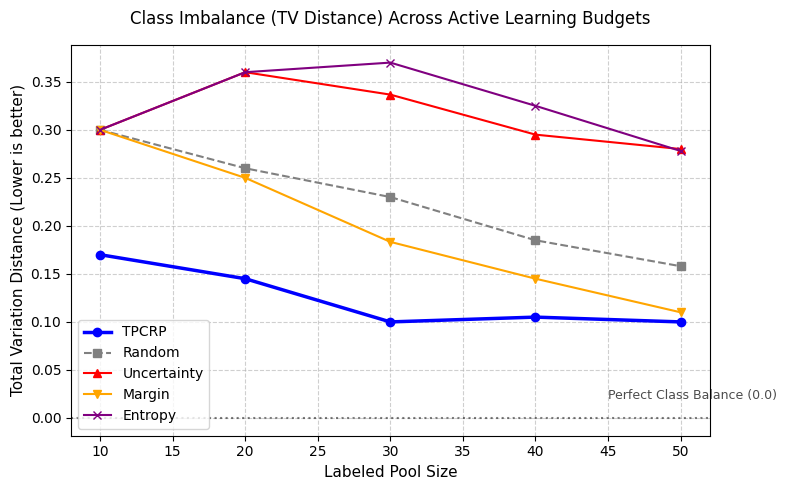

In [18]:
import matplotlib.pyplot as plt

# 1. Load TPCRP and Random (from Cell 9.5)
tv_tpcrp_random = np.load(os.path.join(OUTPUT_DIR, "tv_distances.npz"))
tv_tpcrp  = tv_tpcrp_random["tpcrp"].reshape(N_REPETITIONS, AL_ITERATIONS)
tv_random = tv_tpcrp_random["random"].reshape(N_REPETITIONS, AL_ITERATIONS)

# 2. Load the Baselines (from Cell 14.5)
tv_baselines = np.load(os.path.join(OUTPUT_DIR, "baseline_tv_distances.npz"))
tv_unc = tv_baselines["unc"]
tv_mar = tv_baselines["mar"]
tv_ent = tv_baselines["ent"]

# Calculate X-axis (Budget sizes: 10, 20, 30, 40, 50)
budgets = [AL_BUDGET + i * AL_BUDGET for i in range(AL_ITERATIONS)]

# Generate the Plot
plt.figure(figsize=(8, 5))

plt.plot(budgets, tv_tpcrp.mean(axis=0), marker='o', label='TPCRP', linewidth=2.5, color='blue')
plt.plot(budgets, tv_random.mean(axis=0), marker='s', label='Random', linestyle='--', color='gray')
plt.plot(budgets, tv_unc.mean(axis=0), marker='^', label='Uncertainty', color='red')
plt.plot(budgets, tv_mar.mean(axis=0), marker='v', label='Margin', color='orange')
plt.plot(budgets, tv_ent.mean(axis=0), marker='x', label='Entropy', color='purple')

plt.title("Class Imbalance (TV Distance) Across Active Learning Budgets", fontsize=12, pad=15)
plt.xlabel("Labeled Pool Size", fontsize=11)
plt.ylabel("Total Variation Distance (Lower is better)", fontsize=11)

# Add a text annotation explaining what 0.0 means for your report
plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5)
plt.text(budgets[-1]-5, 0.02, 'Perfect Class Balance (0.0)', color='black', alpha=0.7, fontsize=9)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot for your Overleaf LaTeX report
plot_path = os.path.join(OUTPUT_DIR, "tv_distance_all_methods.png")
plt.savefig(plot_path, dpi=300)
print(f"High-res plot saved to: {plot_path}")

plt.show()

## Cell 16 - Baseline Selection Functions (Uncertainty/Margin/Entropy)

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LinearClassifier(nn.Module):
    """Linear classifier for Framework (ii) - trains on embeddings"""
    def __init__(self, input_dim=512, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)
        
    def forward(self, x):
        return self.fc(x)

def uncertainty_select(classifier, unlabeled_indices, B):
    classifier.cpu().eval()
    with torch.no_grad():
        unlabeled_embeddings = torch.tensor(embeddings[unlabeled_indices]).float()
        logits = classifier(unlabeled_embeddings)
        probs = F.softmax(logits, dim=1)
        max_probs, _ = torch.max(probs, dim=1)
        _, top_indices = torch.sort(max_probs, descending=False)
        selected = top_indices[:B].tolist()
        return [unlabeled_indices[i] for i in selected]

def margin_select(classifier, unlabeled_indices, B):
    classifier.cpu().eval()
    with torch.no_grad():
        unlabeled_embeddings = torch.tensor(embeddings[unlabeled_indices]).float()
        logits = classifier(unlabeled_embeddings)
        probs = F.softmax(logits, dim=1)
        sorted_probs, _ = torch.sort(probs, dim=1, descending=True)
        margins = sorted_probs[:, 0] - sorted_probs[:, 1]
        _, top_indices = torch.sort(margins, descending=False)
        selected = top_indices[:B].tolist()
        return [unlabeled_indices[i] for i in selected]

def entropy_select(classifier, unlabeled_indices, B):
    classifier.cpu().eval()
    with torch.no_grad():
        unlabeled_embeddings = torch.tensor(embeddings[unlabeled_indices]).float()
        logits = classifier(unlabeled_embeddings)
        probs = F.softmax(logits, dim=1)
        entropy = - (probs * torch.log(probs + 1e-10)).sum(dim=1)
        _, top_indices = torch.sort(entropy, descending=True)
        selected = top_indices[:B].tolist()
        return [unlabeled_indices[i] for i in selected]


## Cell 17 - Generalised AL Loop for Baselines

In [ ]:
# def run_al_baseline(strategy_name, select_fn, N_REPS=10, load_if_exists=True):
#     summary_csv_path = os.path.join(OUTPUT_DIR, f"acc_{strategy_name}_summary.csv")
    
#     # Skip if we already have the summary file
#     if load_if_exists and os.path.exists(summary_csv_path):
#         print(f"Loaded existing summary for {strategy_name}")
#         return
        
#     # Store all results in memory before saving
#     all_reps_accs = np.zeros((N_REPS, AL_ITERATIONS))
    
#     for rep in range(N_REPS):
#         rep_seed = 42 + rep
#         set_seed(rep_seed)
#         rng = np.random.default_rng(rep_seed)
        
#         # Initialise identical starting pool (L0)
#         L0_indices = tpcrp_select(embeddings, set(), AL_BUDGET, rng)
#         labeled_set = set(L0_indices)
#         unlabeled_indices = [i for i in range(N_TRAIN) if i not in labeled_set]
        
#         acc_list = []
        
#         for t in range(1, AL_ITERATIONS + 1):
#             clf_seed = rep_seed * 100 + (t - 1)
            
#             # 1. Train and evaluate
#             acc = train_classifier_optimized(labeled_set, seed=clf_seed)
#             acc_list.append(acc)
#             print(f"  [{strategy_name.capitalize():<11}] rep {rep} iter {t} |L|={len(labeled_set):3d} acc={acc:.2f}%")
            
#             if t == AL_ITERATIONS:
#                 break
                
#             # 2. Retrain linear model for sample selection
#             set_seed(clf_seed)
#             classifier = LinearClassifier(EMBED_DIM, 10).to(DEVICE)
#             optimizer = optim.SGD(classifier.parameters(), lr=CLF_LR, momentum=CLF_MOMENTUM, weight_decay=CLF_WD, nesterov=True)
#             scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CLF_EPOCHS)
#             criterion = nn.CrossEntropyLoss()
            
#             x_train = torch.tensor(embeddings[list(labeled_set)]).float().to(DEVICE)
#             y_train = torch.tensor(train_labels[list(labeled_set)]).long().to(DEVICE)
#             dataset = torch.utils.data.TensorDataset(x_train, y_train)
#             loader = torch.utils.data.DataLoader(dataset, batch_size=min(64, len(labeled_set)), shuffle=True)
            
#             classifier.train()
#             for _ in range(CLF_EPOCHS):
#                 for x_b, y_b in loader:
#                     optimizer.zero_grad()
#                     loss = criterion(classifier(x_b), y_b)
#                     loss.backward()
#                     optimizer.step()
#                 scheduler.step()
                
#             # 3. Select new samples
#             new_indices = select_fn(classifier, unlabeled_indices, AL_BUDGET)
#             labeled_set.update(new_indices)
#             unlabeled_indices = [i for i in unlabeled_indices if i not in new_indices]
            
#         # Store this repetition's results
#         all_reps_accs[rep] = acc_list
        
#     # Calculate mean and standard error across all reps
#     mean_acc = all_reps_accs.mean(axis=0)
#     se_acc = all_reps_accs.std(axis=0, ddof=1) / np.sqrt(N_REPS)
    
#     # Save ONE summary file containing the means and standard errors
#     with open(summary_csv_path, 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(mean_acc)
#         writer.writerow(se_acc)
        
#     print(f"Saved aggregated summary -> {summary_csv_path}")

In [ ]:
def run_al_baseline(strategy_name, select_fn, N_REPS=10, load_if_exists=True):
    summary_csv_path = os.path.join(OUTPUT_DIR, f"acc_{strategy_name}_summary.csv")
    tv_csv_path = os.path.join(OUTPUT_DIR, f"tv_{strategy_name}_summary.csv")
    
    if load_if_exists and os.path.exists(summary_csv_path) and os.path.exists(tv_csv_path):
        print(f"Loaded existing summaries for {strategy_name}")
        return
        
    all_reps_accs = np.zeros((N_REPS, AL_ITERATIONS))
    all_reps_tvs = np.zeros((N_REPS, AL_ITERATIONS))  # NEW: Track TV
    
    for rep in range(N_REPS):
        rep_seed = 42 + rep
        set_seed(rep_seed)
        rng = np.random.default_rng(rep_seed)
        
        L0_indices = tpcrp_select(embeddings, set(), AL_BUDGET, rng)
        labeled_set = set(L0_indices)
        unlabeled_indices = [i for i in range(N_TRAIN) if i not in labeled_set]
        
        acc_list = []
        tv_list = []  # NEW: Track TV for this repetition
        
        for t in range(1, AL_ITERATIONS + 1):
            clf_seed = rep_seed * 100 + (t - 1)
            
            # 1. Train and evaluate
            acc = train_classifier_optimized(labeled_set, seed=clf_seed)
            acc_list.append(acc)
            
            # *** NEW: Calculate and store TV distance for the current labeled set ***
            current_tv = total_variation_distance(list(labeled_set))
            tv_list.append(current_tv)
            
            print(f"  [{strategy_name.capitalize():<11}] rep {rep} iter {t} |L|={len(labeled_set):3d} acc={acc:.2f}% TV={current_tv:.3f}")
            
            if t == AL_ITERATIONS:
                break
                
            # 2. Retrain linear model for sample selection
            set_seed(clf_seed)
            classifier = LinearClassifier(EMBED_DIM, 10).to(DEVICE)
            optimizer = optim.SGD(classifier.parameters(), lr=CLF_LR, momentum=CLF_MOMENTUM, weight_decay=CLF_WD, nesterov=True)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CLF_EPOCHS)
            criterion = nn.CrossEntropyLoss()
            
            x_train = torch.tensor(embeddings[list(labeled_set)]).float().to(DEVICE)
            y_train = torch.tensor(train_labels[list(labeled_set)]).long().to(DEVICE)
            dataset = torch.utils.data.TensorDataset(x_train, y_train)
            loader = torch.utils.data.DataLoader(dataset, batch_size=min(64, len(labeled_set)), shuffle=True)
            
            classifier.train()
            for _ in range(CLF_EPOCHS):
                for x_b, y_b in loader:
                    optimizer.zero_grad()
                    loss = criterion(classifier(x_b), y_b)
                    loss.backward()
                    optimizer.step()
                scheduler.step()
                
            # 3. Select new samples
            new_indices = select_fn(classifier, unlabeled_indices, AL_BUDGET)
            labeled_set.update(new_indices)
            unlabeled_indices = [i for i in unlabeled_indices if i not in new_indices]
            
        all_reps_accs[rep] = acc_list
        all_reps_tvs[rep] = tv_list  # NEW: Store TV results
        
    # Save ACCURACY summary
    with open(summary_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(all_reps_accs.mean(axis=0))
        writer.writerow(all_reps_accs.std(axis=0, ddof=1) / np.sqrt(N_REPS))
        
    # Save TV DISTANCE summary
    with open(tv_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(all_reps_tvs.mean(axis=0))
        writer.writerow(all_reps_tvs.std(axis=0, ddof=1) / np.sqrt(N_REPS))
        
    print(f"Saved aggregated summaries -> {strategy_name}")

In [28]:
# Run all baselines (this will only generate 3 summary files total)
run_al_baseline('uncertainty', uncertainty_select)
run_al_baseline('margin', margin_select)
run_al_baseline('entropy', entropy_select)

import plotly.graph_objects as go
import numpy as np
import os
import csv

# Updated loader to read the single summary file
def load_baseline_summary(strategy_name):
    csv_path = os.path.join(OUTPUT_DIR, f"acc_{strategy_name}_summary.csv")
    with open(csv_path, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)
        mean_acc = np.array([float(x) for x in rows[0]])
        se_acc = np.array([float(x) for x in rows[1]])
    return mean_acc, se_acc

# Load our newly aggregated data
unc_mean, unc_se = load_baseline_summary('uncertainty')
mar_mean, mar_se = load_baseline_summary('margin')
ent_mean, ent_se = load_baseline_summary('entropy')

iterations = list(range(1, AL_ITERATIONS + 1))
x_labels = [f"Iter {i}<br>({i*AL_BUDGET} labels)" for i in iterations]

fig = go.Figure()

# Plot TPCRP
fig.add_trace(go.Scatter(
    x=iterations, y=tpcrp_mean.tolist(),
    mode="lines+markers", name="TPCRP (SimCLR + K-means)",
    line=dict(width=2.5, color="#636efa"), marker=dict(size=8, symbol="circle"),
    error_y=dict(type="data", array=tpcrp_se.tolist(), visible=True, thickness=1.5, width=6),
))

# Plot Random Baseline
fig.add_trace(go.Scatter(
    x=iterations, y=random_mean.tolist(),
    mode="lines+markers", name="Random",
    line=dict(width=2.5, color="#EF553B"), marker=dict(size=8, symbol="square"),
    error_y=dict(type="data", array=random_se.tolist(), visible=True, thickness=1.5, width=6),
))

# Plot Uncertainty
fig.add_trace(go.Scatter(
    x=iterations, y=unc_mean.tolist(),
    mode="lines+markers", name="Uncertainty",
    line=dict(width=2.5, color="#00cc96"), marker=dict(size=8, symbol="triangle-up"),
    error_y=dict(type="data", array=unc_se.tolist(), visible=True, thickness=1.5, width=6),
))

# Plot Margin
fig.add_trace(go.Scatter(
    x=iterations, y=mar_mean.tolist(),
    mode="lines+markers", name="Margin",
    line=dict(width=2.5, color="#FFA15A"), marker=dict(size=8, symbol="diamond"),
    error_y=dict(type="data", array=mar_se.tolist(), visible=True, thickness=1.5, width=6),
))

# Plot Entropy
fig.add_trace(go.Scatter(
    x=iterations, y=ent_mean.tolist(),
    mode="lines+markers", name="Entropy",
    line=dict(width=2.5, color="#ab63fa"), marker=dict(size=8, symbol="x"),
    error_y=dict(type="data", array=ent_se.tolist(), visible=True, thickness=1.5, width=6),
))

fig.update_layout(
    height=550, margin=dict(t=120, b=60, l=60, r=40),
    title=dict(
        text=("TPCRP vs Baselines - CIFAR-10 Low Budget<br>"
              "<span style='font-size:15px;font-weight:normal;'>"
              "Source: Hacohen et al. ICML 2022 | Fully supervised, B=10, 10 reps</span>"),
        y=0.94, x=0.5, xanchor='center', yanchor='top',
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
    xaxis=dict(tickmode="array", tickvals=iterations, ticktext=x_labels, title_text="AL Iteration"),
    yaxis_title="Test Accuracy (%)",
)

fig.update_traces(cliponaxis=False)
plot_path = os.path.join(OUTPUT_DIR, "tpcrp_vs_all_baselines_cifar10.png")
fig.write_image(plot_path, scale=2)
print(f"Plot saved → {plot_path}")
fig.show()

Loaded existing summaries for uncertainty
Loaded existing summaries for margin
Loaded existing summaries for entropy
Plot saved → output/tpcrp_vs_all_baselines_cifar10.png


## TV distance

In [23]:
tv_results_path = os.path.join(OUTPUT_DIR, "tv_distances_tpcrp_random.npz")

def total_variation_distance(labeled_indices):
    """TV distance between labeled set class dist and true uniform (1/10 per class)."""
    # Cast to numpy array in case train_labels is a list or tensor
    labels_array = np.array(train_labels) 
    label_dist = np.bincount(labels_array[labeled_indices], minlength=10)
    label_dist = label_dist / label_dist.sum()
    true_dist = np.ones(10) / 10
    return 0.5 * np.sum(np.abs(label_dist - true_dist))

if os.path.exists(tv_results_path):
    print("[TV Distance] Loading cached results for TPCRP & Random…")
    _saved_tv = np.load(tv_results_path)
    tv_tpcrp = _saved_tv["tpcrp"]
    tv_random = _saved_tv["random"]
else:
    # Initialise as 2D arrays: (Reps, Iters)
    tv_tpcrp = np.zeros((N_REPETITIONS, AL_ITERATIONS))
    tv_random = np.zeros((N_REPETITIONS, AL_ITERATIONS))

    set_seed(42)
    for rep in range(N_REPETITIONS):
        rep_seed = 1000 + rep * 13
        rng_tp   = np.random.default_rng(rep_seed)
        rng_rand = np.random.default_rng(rep_seed)

        labeled_tp   = set()
        labeled_rand = set()

        for it in range(AL_ITERATIONS):
            labeled_tp.update(tpcrp_select(embeddings, labeled_tp, AL_BUDGET, rng_tp))
            labeled_rand.update(random_select(labeled_rand, AL_BUDGET, N_TRAIN, rng_rand))

            # Store in the 2D matrix
            tv_tpcrp[rep, it] = total_variation_distance(list(labeled_tp))
            tv_random[rep, it] = total_variation_distance(list(labeled_rand))

    np.savez(tv_results_path, tpcrp=tv_tpcrp, random=tv_random)
    print(f"[TV Distance] Results saved → {tv_results_path}")

[TV Distance] Results saved → ./output/tv_distances_tpcrp_random.npz


In [24]:
import os
import csv
import numpy as np
import plotly.graph_objects as go
import json

# --- 1. Settings & Data Loading ---
OUTPUT_DIR = "output"  # Change if your directory is different
AL_ITERATIONS = 5
AL_BUDGET = 10
iterations = list(range(1, AL_ITERATIONS + 1))
x_labels = [f"Iter {i}<br>({i*AL_BUDGET} labels)" for i in iterations]

def load_tv_summary_csv(strategy_name):
    """Loads TV distance mean and SE from the newly generated CSVs."""
    csv_path = os.path.join(OUTPUT_DIR, f"tv_{strategy_name}_summary.csv")
    with open(csv_path, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)
        mean_tv = np.array([float(x) for x in rows[0]])
        se_tv = np.array([float(x) for x in rows[1]])
    return mean_tv, se_tv

def load_tv_npz():
    """Loads TPCRP and Random from the updated .npz file and calculates mean/SE."""
    npz_path = os.path.join(OUTPUT_DIR, "tv_distances_tpcrp_random.npz")
    data = np.load(npz_path)
    
    tpcrp_raw = data["tpcrp"]   # Shape: (10, 5)
    random_raw = data["random"] # Shape: (10, 5)
    
    n_reps = tpcrp_raw.shape[0]
    
    tpcrp_mean = tpcrp_raw.mean(axis=0)
    tpcrp_se = tpcrp_raw.std(axis=0, ddof=1) / np.sqrt(n_reps)
    
    random_mean = random_raw.mean(axis=0)
    random_se = random_raw.std(axis=0, ddof=1) / np.sqrt(n_reps)
    
    return tpcrp_mean, tpcrp_se, random_mean, random_se

# Load the data
tv_tpcrp_mean, tv_tpcrp_se, tv_random_mean, tv_random_se = load_tv_npz()
tv_unc_mean, tv_unc_se = load_tv_summary_csv('uncertainty')
tv_mar_mean, tv_mar_se = load_tv_summary_csv('margin')
tv_ent_mean, tv_ent_se = load_tv_summary_csv('entropy')

# --- 2. Build the Plot ---
fig = go.Figure()

# Helper function to add traces with shaded SE bands
def add_strategy_trace(fig, mean_arr, se_arr, name, color, symbol, dash="solid"):
    # Main line
    fig.add_trace(go.Scatter(
        x=iterations, y=mean_arr.tolist(),
        mode="lines+markers", name=name,
        line=dict(width=2.5, color=color, dash=dash), 
        marker=dict(size=8, symbol=symbol),
        error_y=dict(type="data", array=se_arr.tolist(), visible=True, thickness=1.5, width=6),
    ))
    # Shaded SE Band
    fig.add_trace(go.Scatter(
        x=iterations + iterations[::-1],
        y=(mean_arr + se_arr).tolist() + (mean_arr - se_arr).tolist()[::-1],
        fill="toself", fillcolor=color.replace("rgb", "rgba").replace(")", ",0.15)"),
        line=dict(color="rgba(255,255,255,0)"), showlegend=False, hoverinfo="skip",
    ))

# Add all strategies matching the accuracy plot colors
add_strategy_trace(fig, tv_tpcrp_mean, tv_tpcrp_se, "TPCRP (SimCLR + K-means)", "rgb(99,110,250)", "circle")
add_strategy_trace(fig, tv_random_mean, tv_random_se, "Random", "rgb(239,85,59)", "square", dash="dash")
add_strategy_trace(fig, tv_unc_mean, tv_unc_se, "Uncertainty", "rgb(0,204,150)", "triangle-up")
add_strategy_trace(fig, tv_mar_mean, tv_mar_se, "Margin", "rgb(255,161,90)", "diamond")
add_strategy_trace(fig, tv_ent_mean, tv_ent_se, "Entropy", "rgb(171,99,250)", "x")

# Add the "Perfect Balance" baseline at y=0
fig.add_hline(y=0.0, line_dash="dot", line_color="black", opacity=0.6,
              annotation_text="Perfect Class Balance (0.0)", 
              annotation_position="bottom right",
              annotation_font_size=12, annotation_font_color="black")

# --- 3. Layout & Formatting ---
fig.update_layout(
    height=550,
    margin=dict(t=120, b=60, l=60, r=40),
    title=dict(
        text=(
            "Class Imbalance (TV Distance) Across AL Budgets"
            "<br><span style='font-size:15px;font-weight:normal;'>"
            "Source: Hacohen et al. ICML 2022 | Lower is better (0.0 = perfectly balanced)</span>"
        ),
        y=0.94, x=0.5, xanchor='center', yanchor='top',
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
    xaxis=dict(
        tickmode="array", tickvals=iterations, ticktext=x_labels, title_text="AL Iteration",
    ),
    yaxis_title="Total Variation Distance",
)

fig.update_traces(cliponaxis=False)

# --- 4. Saving ---
plot_path = os.path.join(OUTPUT_DIR, "tv_distance_all_methods_plotly.png")
fig.write_image(plot_path, scale=2)

# Save Metadata for Overleaf
with open(plot_path + ".meta.json", "w") as fh:
    json.dump({
        "caption": "Class imbalance measured by Total Variation (TV) distance across active learning iterations.",
        "description": "TPCRP maintains a much lower TV distance (closer to 0.0) compared to Uncertainty, Margin, and Entropy, which heavily skew the dataset towards confusing classes.",
    }, fh, indent=4)

print(f"High-res TV distance plot saved → {plot_path}")
fig.show()

High-res TV distance plot saved → output/tv_distance_all_methods_plotly.png
